In [133]:
import pandas as pd
import numpy as np
import os, glob
import re
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, mean_absolute_percentage_error, mean_squared_log_error, root_mean_squared_error, root_mean_squared_error

In [468]:
df = pd.read_csv('./total_data.csv')
raw_data = df[['DFT', '7net-0', '7net-l3i5', '7net-omat',
       '7net-ompa-mpa', '7net-ompa-omat24', '7net-omni-mpa','7net-omni-omat24',
        'orb_mpa', 'orb_omat']]
raw_data.to_csv('./raw_data.csv', index=False)
true_value = df['DFT']
mlips = raw_data.drop(columns=['DFT','7net-0','7net-l3i5','7net-omat'])
mlips.to_csv('./mlips.csv', index=False)

In [469]:
len(mlips.columns)
mlip_list = mlips.columns.to_list()
config_list = [
    "a1", "a2",
    "b1", "b2", "b3",
    "c1", "c2",
    "d", "e", "f", "g", "h", "i",
    "j", "k", "Co", "Cr", "Cu","Mn", "Mo","Nb", "Ni","Ti", "V"
]
len(config_list)

24

In [470]:
sns_df = pd.DataFrame(columns=['config','dft', 'mlip', 'pred','delta','abs_error'], index=range(9*24))
idx = 0
for i in range(15):
    for mlip in mlips.columns:
        sns_df.loc[idx, 'config'] = config_list[i]
        sns_df.loc[idx, 'dft'] = true_value[i]
        sns_df.loc[idx, 'mlip'] = mlip
        sns_df.loc[idx, 'pred'] = mlips.loc[i, mlip]
        sns_df.loc[idx, 'delta'] = mlips.loc[i, mlip] - true_value[i]
        sns_df.loc[idx, 'abs_error'] = abs(mlips.loc[i, mlip] - true_value[i])
        idx += 1
sns_df.to_csv('./sns_data.csv', index=False)

In [471]:
metrics = pd.DataFrame(columns = mlips.columns)
for col in mlips.columns:
    pred_value = mlips[col]
    metrics.loc['MAE', col] = mean_absolute_error(true_value, pred_value)
    metrics.loc['MSE', col] = mean_squared_error(true_value, pred_value)
    metrics.loc['RMSE', col] = np.sqrt(mean_squared_error(true_value, pred_value))
    metrics.loc['R2', col] = r2_score(true_value, pred_value)
    # metrics.loc['Explained Variance', col] = explained_variance_score(true_value, pred_value)
    metrics.loc['MAPE', col] = mean_absolute_percentage_error(true_value, pred_value)
    try:
        metrics.loc['MSLE', col] = mean_squared_log_error(true_value, pred_value)
        metrics.loc['RMSLE', col] = np.sqrt(mean_squared_log_error(true_value, pred_value))
    except:
        metrics.loc['MSLE', col] = 'NA'
        metrics.loc['RMSLE', col] = 'NA'
metrics.to_csv('./mlip_metric.csv')
print(metrics)



      7net-ompa-mpa 7net-ompa-omat24 7net-omni-mpa 7net-omni-omat24   orb_mpa  \
MAE        0.224597         0.244258      0.211286         0.203856  0.198242   
MSE        0.094476         0.107484       0.07199         0.066835  0.049503   
RMSE        0.30737         0.327848       0.26831         0.258525  0.222493   
R2          0.80931         0.783056      0.854696         0.865101  0.900084   
MAPE       1.893772         2.146718      1.278664         1.334508  1.414497   
MSLE             NA               NA            NA               NA        NA   
RMSLE            NA               NA            NA               NA        NA   

       orb_omat  
MAE    0.162272  
MSE    0.043231  
RMSE    0.20792  
R2     0.912744  
MAPE   0.735543  
MSLE         NA  
RMSLE        NA  


In [472]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica','Arial']
# plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titlelocation'] = 'right'
plt.rcParams['axes.titlepad'] = 3

plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.labelbottom'] = True    
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.loc'] = 'lower right'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'in'

plt.rcParams['xtick.major.size'] = 7
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.3

plt.rcParams['ytick.major.size'] = 7
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 0.3
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.facecolor'] = 'white'

plt.rcParams['figure.figsize'] = 3.4, 2.5
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['figure.subplot.bottom'] = 0.18
plt.rcParams['figure.subplot.left'] = 0.1
plt.rcParams['figure.subplot.right'] = 0.97
plt.rcParams['figure.subplot.top'] = 0.98
plt.rcParams['figure.subplot.wspace'] = 0.05
plt.rcParams['figure.subplot.hspace'] = 0.03


color_dict= {
    '7net-ompa-omat24': '#02baae',
    '7net-ompa-mpa': '#72b8b3',
    '7net-omat': '#c1ded8',
    '7net-omni-omat24': '#0073ff',
    '7net-omni-mpa': '#8cbbf5',
    '7net-l3i5': '#0a8a2c',
    '7net-0': '#89c99a',
    'orb_omat': '#d48f3f',
    'orb_mpa': '#d9ba98',
    'esen_omat':'#b2bd42',
    'esen_oam': '#d3d998',
    
}

label_dict = {
    '7net-0': '7net-0',
    '7net-l3i5': '7net-l3i5',
    '7net-omat': '7net-omat',
    '7net-ompa-mpa': 'ompa-mpa',
    '7net-ompa-omat24': 'ompa-omat24',
    '7net-omni-omat24': 'omni-omat24',
    '7net-omni-mpa': 'omni-mpa',
    'orb_mpa': 'Orb-mpa',
    'orb_omat': 'Orb-omat',
    'esen_oam': 'eSEN-oam',
    'esen_omat': 'eSEN-omat',
    
}

mpa_list = ['7net-0', '7net-l3i5', '7net-ompa-mpa', '7net-omni-mpa', 'orb_mpa',]
omat_list = ['7net-omat', '7net-ompa-omat24', '7net-omni-omat24', 'orb_omat',]
all_list = mlips.columns.to_list()


In [473]:
sns_mpa = sns_df[sns_df['mlip'].isin(mpa_list)]
sns_omat = sns_df[sns_df['mlip'].isin(omat_list)]
sns_all = sns_df[sns_df['mlip'].isin(all_list)]
sns_all.to_csv('./sns_all.csv', index=False)
sns_mpa.to_csv('./sns_mpa.csv', index=False)
sns_omat.to_csv('./sns_omat.csv', index=False)

In [476]:
def plot_box(type='all'):
    if type == 'all':
        data = sns_all
        save_name = 'box_all.png'
        mlip_list = all_list
        vline = [0.5, 1.5, 2.5, 3.5, 4.5]
    elif type == 'mpa':
        data = sns_mpa
        save_name = 'box_mpa.png'
        mlip_list = mpa_list
        vline = [0.5]
    elif type == 'omat':
        data = sns_omat
        save_name = 'box_omat.png'
        mlip_list = omat_list
        vline = [0.5]
    else:
        print('Error: type should be all, mpa or omat')
        return
    
    plt.figure(figsize=(10,6.5))

    sns.boxplot(
        data=data,
        x="mlip",
        y="delta",
        palette=color_dict,
        whis=(5, 95),
        showfliers=True,
        width=0.6
    )
    plt.xticks(ticks=range(len(mlip_list)), labels=[label_dict[i] for i in mlip_list], ha='center')
    ylabel = r"$\Delta E_{\mathrm{bind}}$ (eV)"
    plt.axhline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
    for v in vline:
        plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
    plt.ylabel(r"$\Delta E_{\mathrm{bind}}$ (eV)")
    plt.xlabel("")
    if type == 'all':
        plt.yticks(np.arange(-0.75, 0.8, 0.25))
        plt.ylim(-1, 0.65)
        plt.xticks(rotation=30)
    elif type == 'mpa':
        plt.yticks(np.arange(-0.75, 0.8, 0.25))
        plt.ylim(-1, 0.65)
        plt.xticks(rotation=0)
    elif type == 'omat':
        plt.ylim(-0.3, 0.7)
        plt.yticks(np.arange(-0.3, 0.8, 0.2))
        plt.xticks(rotation=0)
        
    plt.tick_params(axis="x", which="major", pad=5)
    plt.savefig(save_name, transparent=True)
    # plt.close()
    plt.show()
    print(f'Box plot saved as {save_name}')


/var/folders/s6/8wvn2dhd0jj9m3bd1l0c6lnm0000gn/T/ipykernel_88274/116614642.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


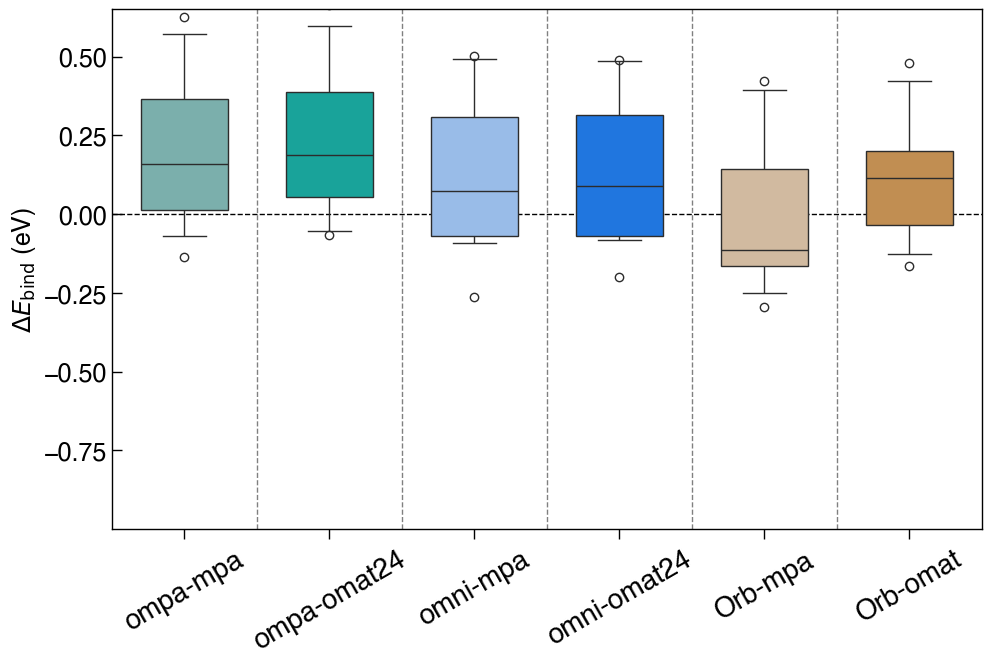

Box plot saved as box_all.png


In [477]:
plot_box('all')

In [467]:
metrics

,7net-0,7net-l3i5,7net-omat,7net-ompa-mpa,7net-ompa-omat24,7net-omni-mpa,7net-omni-omat24,orb_mpa,orb_omat
MAE,0.271125,0.55456,0.189185,0.224597,0.244258,0.211286,0.203856,0.198242,0.162272
MSE,0.13319,0.46054,0.072769,0.094476,0.107484,0.07199,0.066835,0.049503,0.043231
RMSE,0.364951,0.678631,0.269758,0.30737,0.327848,0.26831,0.258525,0.222493,0.20792
R2,0.731173,0.070454,0.853124,0.80931,0.783056,0.854696,0.865101,0.900084,0.912744
MAPE,1.581783,4.03633,0.700134,1.893772,2.146718,1.278664,1.334508,1.414497,0.735543
MSLE,NA,NA,NA,NA,NA,NA,NA,NA,NA
RMSLE,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [445]:
# for each model, pick top 2 abs_error rows
# sns_df.drop(columns=['pred'], inplace=True)
top2 = (sns_df.groupby("mlip", group_keys=False)
                 .apply(lambda g: g.min()))

print(top2)

                 config              mlip     delta
mlip                                               
7net-0               a1            7net-0 -0.745728
7net-l3i5            a1         7net-l3i5 -1.553398
7net-omat            a1         7net-omat -0.101226
7net-omni-mpa        a1     7net-omni-mpa -0.264038
7net-omni-omat24     a1  7net-omni-omat24 -0.200317
7net-ompa-mpa        a1     7net-ompa-mpa -0.135620
7net-ompa-omat24     a1  7net-ompa-omat24 -0.067349
esen_oam             a1          esen_oam -0.187500
esen_omat            a1         esen_omat -0.196533
orb_mpa              a1           orb_mpa -0.295132
orb_omat             a1          orb_omat -0.163726


/var/folders/s6/8wvn2dhd0jj9m3bd1l0c6lnm0000gn/T/ipykernel_88274/4175288960.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.min()))
